<a href="https://colab.research.google.com/github/samuel-lynz/BrainTumorModel/blob/main/AI_ModelBrainTumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU Available: []


In [2]:
# ====================== 2. SET PATHS (CORRECT) ======================
drive.mount('/content/drive')

base_dir = r"/content/drive/MyDrive/Colab Notebooks/archive"

train_dir = os.path.join(base_dir, "Training")
test_dir  = os.path.join(base_dir, "Testing")

print("Training path:", train_dir)
print("Testing path :", test_dir)
print("Training exists:", os.path.exists(train_dir))
print("Testing exists :", os.path.exists(test_dir))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training path: /content/drive/MyDrive/Colab Notebooks/archive/Training
Testing path : /content/drive/MyDrive/Colab Notebooks/archive/Testing
Training exists: True
Testing exists : True


In [3]:
# ====================== 3. SETTINGS ======================
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

In [4]:
# ====================== 4. DATA GENERATORS ======================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)


Found 2441 images belonging to 4 classes.
Found 429 images belonging to 4 classes.
Found 394 images belonging to 4 classes.

Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [5]:
# ====================== 5. BUILD MODEL ======================
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
# ====================== 6. CALLBACKS ======================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_brain_tumor_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]


In [7]:
# ====================== 7. TRAIN THE MODEL ======================
print("\n----- Starting Training -----")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)


----- Starting Training -----
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2758 - loss: 1.4208
Epoch 1: val_accuracy improved from None to 0.28904, saving model to best_brain_tumor_model.h5



Epoch 1: finished saving model to best_brain_tumor_model.h5
77/77 ━━━━━━━━━━━━━━━━━━━━ 699s 9s/step - accuracy: 0.2737 - loss: 1.3963 - val_accuracy: 0.2890 - val_loss: 1.3501 - learning_rate: 0.0010
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2684 - loss: 1.3637
Epoch 2: val_accuracy did not improve from 0.28904
77/77 ━━━━━━━━━━━━━━━━━━━━ 283s 4s/step - accuracy: 0.2782 - loss: 1.3587 - val_accuracy: 0.2890 - val_loss: 1.3481 - learning_rate: 0.0010
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2979 - loss: 1.3535
Epoch 3: val_accuracy did not improve from 0.28904
77/77 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step - accuracy: 0.2954 - loss: 1.3581 - val_accuracy: 0.2867 - val_loss: 1.3498 - learning_rate: 0.0010
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2926 - loss: 1.3479
Epoch 4: val_accuracy did not improve from 0.28904
77/77 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.2872 - loss: 1.3516 - val_accuracy: 0.2890 - val_loss: 1.3483 -

In [8]:

# ====================== 8. FINE-TUNING ======================
print("\n----- Starting Fine-Tuning -----")
base_model.trainable = True

# Freeze first 100 layers
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks
)


----- Starting Fine-Tuning -----
Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2784 - loss: 1.5974
Epoch 1: val_accuracy did not improve from 0.28904
77/77 ━━━━━━━━━━━━━━━━━━━━ 454s 5s/step - accuracy: 0.2991 - loss: 1.5263 - val_accuracy: 0.2867 - val_loss: 1.3527 - learning_rate: 1.0000e-05
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3945 - loss: 1.3527
Epoch 2: val_accuracy did not improve from 0.28904
77/77 ━━━━━━━━━━━━━━━━━━━━ 424s 5s/step - accuracy: 0.3921 - loss: 1.3413 - val_accuracy: 0.2890 - val_loss: 1.3609 - learning_rate: 1.0000e-05
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4056 - loss: 1.2608
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy did not improve from 0.28904
77/77 ━━━━━━━━━━━━━━━━━━━━ 419s 5s/step - accuracy: 0.4203 - loss: 1.2418 - val_accuracy: 0.2844 - val_loss: 1.3565 - learning_rate: 1.0000e-05
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - acc


Epoch 4: finished saving model to best_brain_tumor_model.h5
77/77 ━━━━━━━━━━━━━━━━━━━━ 417s 5s/step - accuracy: 0.4580 - loss: 1.2159 - val_accuracy: 0.2914 - val_loss: 1.3786 - learning_rate: 3.0000e-06
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4648 - loss: 1.1942
Epoch 5: val_accuracy did not improve from 0.29138
77/77 ━━━━━━━━━━━━━━━━━━━━ 416s 5s/step - accuracy: 0.4625 - loss: 1.1931 - val_accuracy: 0.2844 - val_loss: 1.4037 - learning_rate: 3.0000e-06
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4585 - loss: 1.2191
Epoch 6: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.

Epoch 6: val_accuracy improved from 0.29138 to 0.31702, saving model to best_brain_tumor_model.h5



Epoch 6: finished saving model to best_brain_tumor_model.h5
77/77 ━━━━━━━━━━━━━━━━━━━━ 416s 5s/step - accuracy: 0.4539 - loss: 1.2106 - val_accuracy: 0.3170 - val_loss: 1.3523 - learning_rate: 3.0000e-06
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


In [9]:
# ====================== 9. EVALUATE ON TEST SET ======================
print("\n----- Evaluating on Test Set -----")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"✅ Test Loss    : {test_loss:.4f}")



----- Evaluating on Test Set -----
13/13 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step - accuracy: 0.2919 - loss: 1.4123

✅ Test Accuracy: 29.19%
✅ Test Loss    : 1.4123


13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       100
meningioma_tumor       0.29      1.00      0.45       115
        no_tumor       0.00      0.00      0.00       105
 pituitary_tumor       0.00      0.00      0.00        74

        accuracy                           0.29       394
       macro avg       0.07      0.25      0.11       394
    weighted avg       0.09      0.29      0.13       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


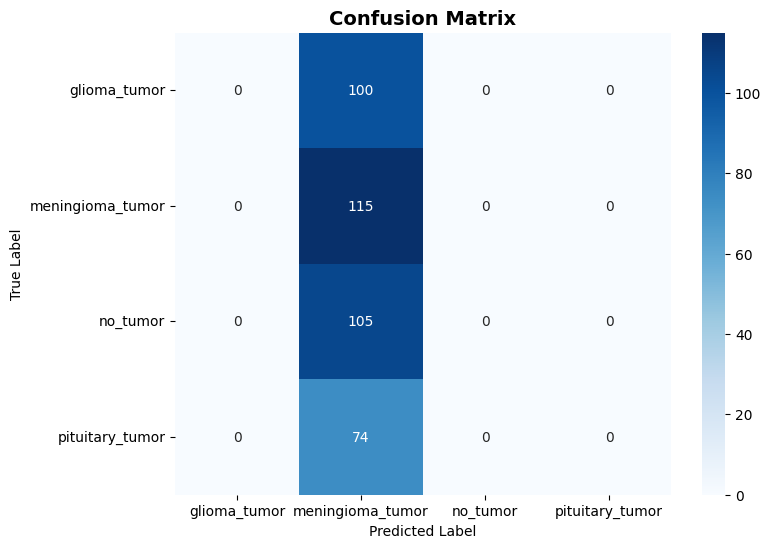

In [10]:
# ====================== 10. PREDICTIONS & METRICS ======================
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(train_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


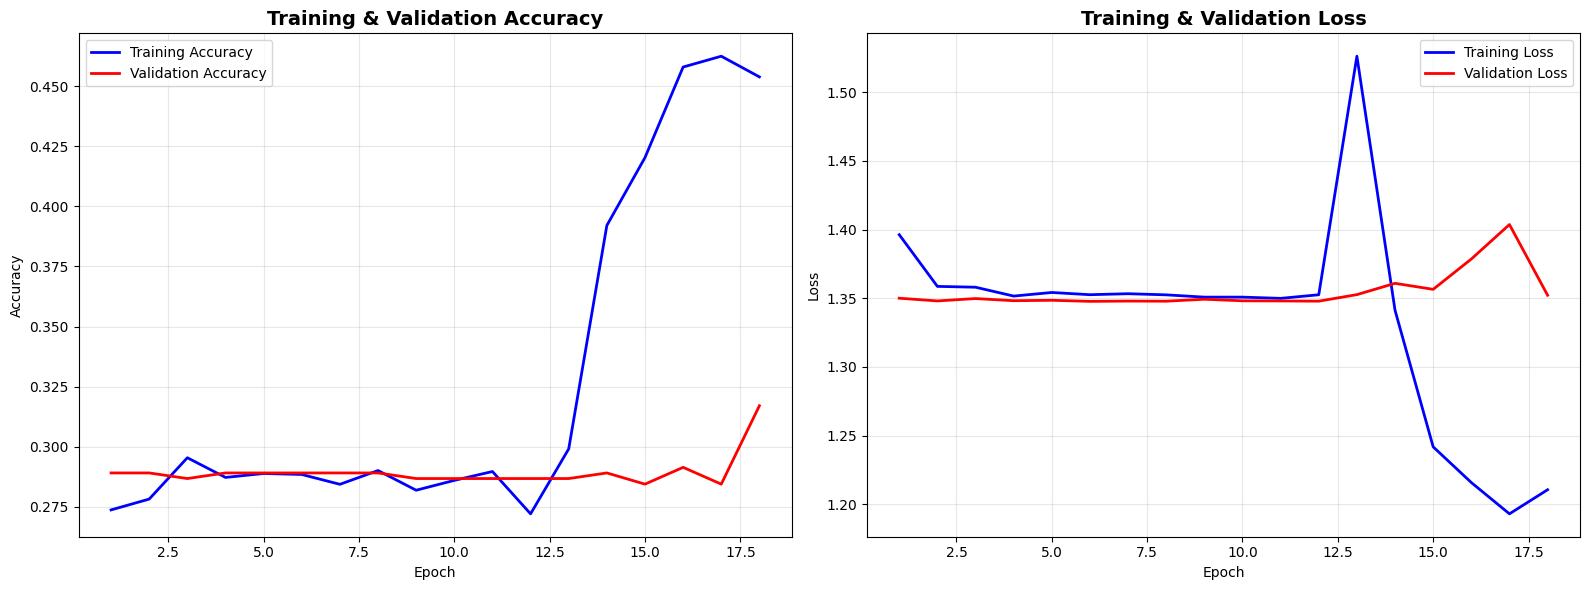

In [11]:
# ====================== 11. LEARNING CURVES (Improved) ======================
def plot_learning_curves(history, history_fine=None):
    if history_fine is not None:
        acc = history.history['accuracy'] + history_fine.history['accuracy']
        val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
        loss = history.history['loss'] + history_fine.history['loss']
        val_loss = history.history['val_loss'] + history_fine.history['val_loss']
    else:
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    plt.title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot learning curves
plot_learning_curves(history, history_fine)



In [12]:
# ====================== 12. SAVE THE MODEL ======================
model.save("brain_tumor_efficientnetb0_final.h5")
print("\n✅ Model saved successfully as 'brain_tumor_efficientnetb0_final.h5'")


✅ Model saved successfully as 'brain_tumor_efficientnetb0_final.h5'
